In [1]:
import sys
sys.path.append('../utils/')
from utils_models import *
from utils_jax import modified_drag_pulse

In [2]:
EJ = 4
EC = 4/5.9
EL = 4/29.2

n_lvls_transmon  = 4
n_lvls_fluxonium = 20

transmon_EJ,g,amp =  [3.56153334e+01, 9.91957369e-02, 2.73280218e-02]

fluxonium = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=transmon_EJ,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )

system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '0,2',
    g_strength = g,
    )

sigma = amp * 108.75  / amp /np.sqrt(2) * 1.15
pulse_length = 6*sigma
beta = 0
tlist = np.linspace(0,pulse_length,4* int(pulse_length))

state_0_dressed = qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,0)])
state_1_dressed = qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed  -  state_1_dressed).unit()
state_plus_i_dressed = (state_0_dressed + 1j * state_1_dressed).unit()
state_minus_i_dressed = (state_0_dressed - 1j * state_1_dressed).unit()
initial_states  = [
    state_0_dressed,
    state_1_dressed,
    state_plus_dressed,
    state_minus_dressed,
    state_plus_i_dressed,
    state_minus_i_dressed,
    ]
     
results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=modified_drag_pulse,
                pulse_shape_args={
                            'w_d': system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]],
                            'amp': amp/(2*np.pi),
                            'duration': pulse_length,
                            'sigma': sigma,
                            'beta':beta
                        } ,
                )],
        c_ops = None,
        e_ops = None,
        post_processing = ['pad_back','partial_trace_computational_states']
    )


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


 Total run time:  49.80s*] Elapsed 49.80s / Remaining 00:00:00:00 [********100%***********] Elapsed 49.70s / Remaining 00:00:00:00


Processing states with pad_back_custom:  30%|██▉       | 633/2120 [00:00<00:00, 6325.77it/s]

 [*********98%***********] Elapsed 50.03s / Remaining 00:00:00:01

Processing states with pad_back_custom:  89%|████████▉ | 1886/2120 [00:00<00:00, 4563.05it/s]

...

Processing states with dressed_to_2_level_dm:  31%|███       | 660/2120 [00:00<00:00, 2180.48it/s]]

 [********100%***********] Elapsed 53.91s / Remaining 00:00:00:00

Processing states with dressed_to_2_level_dm:  80%|███████▉  | 1686/2120 [00:00<00:00, 2139.57it/s]

 Total run time:  53.97s*] Elapsed 53.97s / Remaining 00:00:00:00


Processing states with dressed_to_2_level_dm: 100%|██████████| 2120/2120 [00:01<00:00, 2054.15it/s]


100%|██████████| 2120/2120 [01:34<00:00, 22.47it/s]


Text(0.5, 0, 't (ns)')

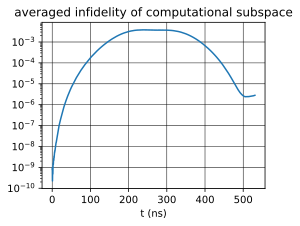

In [3]:
num_time_steps = len(results[0].times)
tlist = results[0].times


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero -  one).unit(),
                (zero + 1j * one).unit(),
                (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity1 = []
phase_lump = []
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_dressed_to_2_level_dm[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase_lump.append(opt_result.x[0])


plt.figure(figsize = (4,3))

plt.plot(tlist,infidelity1,label = rf'$\kappa = 10^{-3}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
# plt.minorticks_on()
# plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

# plt.legend()

plt.yscale('log')
plt.title(rf"""averaged infidelity of computational subspace""")
plt.xlabel("t (ns)")

# Let's look at the product state - dressed state overlap to figure out the situation of the infidelity in the middle

In [6]:
product_to_dressed = system.product_to_dressed
qbt_position = system.qbt_position
filtered_product_to_dressed = system.filtered_product_to_dressed
sign_multiplier = system.sign_multiplier

def convert_to_product_with_first_subsystem_truncated(dressed_dm_data):
    if dressed_dm_data.shape[1] == 1:
        dressed_dm_data = qutip.ket2dm(dressed_dm_data)
    dressed_dm_data = dressed_dm_data.full()

    # Infer subsystem dimensions
    subsystem_dims = [max(indexes) + 1 for indexes in zip(*product_to_dressed.keys())]
    subsystem_dims[qbt_position] = 2
    rho_product = np.zeros((subsystem_dims*2), dtype=complex) # Here rho_product is shaped like (dim1,dim2,dim1,dim2)
    for product_state, dressed_index1 in filtered_product_to_dressed.items():
        for product_state2, dressed_index2 in filtered_product_to_dressed.items():
            element = dressed_dm_data[dressed_index1, dressed_index2] * sign_multiplier[dressed_index1] * sign_multiplier[dressed_index2]
            rho_product[product_state+product_state2] += element # Using index like (lvl1, lvl2, lvl1, lvl2) to access of of the entries
    two_lvl_qbt_dm_size = np.prod(subsystem_dims)
    rho_product = rho_product.reshape((two_lvl_qbt_dm_size,two_lvl_qbt_dm_size))
    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product

def calc_infidelity_with_phase_for_single_osc_lvl(theta,ol, rho, state_ideal):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    gate = qutip.qip.operations.phasegate(theta[0])
    new_ideal = gate*state_ideal

    trunc_dm =qutip.Qobj(rho.full().reshape(rho.dims[0]+rho.dims[1])[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])
    fid = qutip.fidelity(trunc_dm, new_ideal)
    return 1 - fid
    

tot_time = results[0].times[-1]
tlist = np.linspace(0, tot_time, int(tot_time))
slice_interval = 20
new_tlist = tlist[::slice_interval]
num_time_steps = len(new_tlist)


phase1 = [[] for _ in range(4)]
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_pad_back_custom[idx*slice_interval] for result in results]
    dms_two_lvl_qbt = [convert_to_product_with_first_subsystem_truncated(dm) for dm in dms]
    for ol in range(4):
        def objective_function(x):
            infidelities = [calc_infidelity_with_phase_for_single_osc_lvl(x,
                                                                ol,
                                                                dm_two_lvl,
                                                                state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl_qbt,states_ideal)]
            mean = np.mean(infidelities)
            return mean
        x0 = [0.0]
        bounds = [(0, 2 * 3.141592653589793)]
        opt_result = minimize(objective_function, x0,method="COBYLA")
        phase1[ol].append(opt_result.x[0])


100%|██████████| 27/27 [00:06<00:00,  4.36it/s]


In [25]:
convert_to_product_with_first_subsystem_truncated(results[2].states_pad_back_custom[0])

Quantum object: dims = [[2, 4], [2, 4]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0.5 0.  0.  0.  0.5 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.5 0.  0.  0.  0.5 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]]

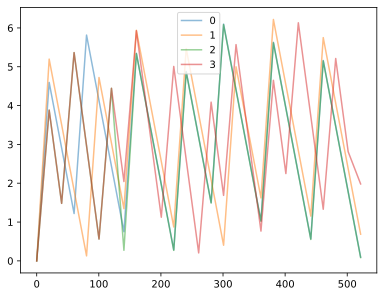

In [30]:
phase_list = np.array(phase1)

evals = system.fluxonium.eigenvals()
omega =  -1*2*np.pi*(system.evals[system.product_to_dressed[(2,0)]] - system.evals[system.product_to_dressed[(0,0)]])
for i in range(4):
    resid = (np.array(phase_list[i]) - np.array(omega*new_tlist))%(2*np.pi)
    plt.plot(new_tlist,resid,label=f"{i}",alpha=0.5)
plt.legend(loc = 'upper center')

# This thing below is importance, it shows that above transmon level=0, the hybrization of fluxonium states prevents direct assignment with dressed states, and hence the infidelity was a mess

In [34]:
evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)

def print_overlap_lists(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlap_matrix[:, product_index][sorted_indices]
    for idx, overlap in zip(sorted_indices[:2], sorted_overlaps[:2]):
        print(f"{idx} , {overlap**2}")


for ql in [0,1,2]:
    for tl in [0,1,2,3]:
        print(f"\nql:{ql}, tl:{tl}")
        print_overlap_lists(ql * system.transmon.truncated_dim + tl)
    print("\n")



ql:0, tl:0
0 , (0.9999355332982109+0j)
15 , (6.261456673894768e-05-0j)

ql:0, tl:1
7 , (-0.7132220485752374+0.6995117286740287j)
3 , (0.0004847250489366355+0.00048125865545327307j)

ql:0, tl:2
21 , (0.9977911095013487+0j)
15 , (0.001505912824726064+0j)

ql:0, tl:3
41 , (0.7228067531877393+0.6851604849066669j)
33 , (-0.0025168131338639747+1.6783161718699435e-05j)



ql:1, tl:0
1 , (0.9735865679375741+0.2280390813684786j)
18 , (-2.5476957384561316e-05-3.238637036867514e-05j)

ql:1, tl:1
11 , (-0.5050217709899448+0j)
9 , (-0.49397012511714394+0j)

ql:1, tl:2
27 , (-0.9226579301922343+0.37489936542513086j)
29 , (-0.0020757222777851906+0.0003510937739460316j)

ql:1, tl:3
46 , (-0.9962992079288112-0j)
42 , (-0.0015864765227143972+0j)



ql:2, tl:0
2 , (0.9999360493515802+0j)
19 , (5.676410675250724e-05+0j)

ql:2, tl:1
10 , (0.39767381365732013+0.9160312297287927j)
5 , (6.191856672256471e-06-0.0005613803800926198j)

ql:2, tl:2
28 , (0.9967562239205087-0j)
25 , (0.0017043120296266773+0j)

ql:

# Let's look at the frequency corresponding to different transmon levels

In [32]:
system.evals[system.product_to_dressed[(2,0)]] - system.evals[system.product_to_dressed[(0,0)]],   \
    system.evals[system.product_to_dressed[(2,1)]] - system.evals[system.product_to_dressed[(0,1)]],   \
    system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(0,2)]],\
    system.evals[system.product_to_dressed[(2,3)]] - system.evals[system.product_to_dressed[(0,3)]]


(2.5731353772006607, 2.5733137617166904, 2.573658891118079, 2.5742708536251584)